In [1]:
import tensorflow as tf
import tensorflow_hub as hub
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

In [2]:
COCO_LABELS = {
    1:"person",2:"bicycle",3:"car",4:"motorcycle",5:"airplane",
    6:"bus",7:"train",8:"truck",9:"boat",10:"traffic light",
    11:"fire hydrant",13:"stop sign",14:"parking meter",15:"bench",
    16:"bird",17:"cat",18:"dog",19:"horse",20:"sheep",21:"cow",
    22:"elephant",23:"bear",24:"zebra",25:"giraffe",27:"backpack",
    28:"umbrella",31:"handbag",32:"tie",33:"suitcase",34:"frisbee",
    35:"skis",36:"snowboard",37:"sports ball",38:"kite",39:"baseball bat",
    40:"baseball glove",41:"skateboard",42:"surfboard",43:"tennis racket",
    44:"bottle",46:"wine glass",47:"cup",48:"fork",49:"knife",50:"spoon",
    51:"bowl",52:"banana",53:"apple",54:"sandwich",55:"orange",
    56:"broccoli",57:"carrot",58:"hot dog",59:"pizza",60:"donut",
    61:"cake",62:"chair",63:"couch",64:"potted plant",65:"bed",
    67:"dining table",70:"toilet",72:"tv",73:"laptop",74:"mouse",
    75:"remote",76:"keyboard",77:"cell phone",78:"microwave",79:"oven",
    80:"toaster",81:"sink",82:"refrigerator",84:"book",85:"clock",
    86:"vase",87:"scissors",88:"teddy bear",89:"hair drier",90:"toothbrush"
}

In [3]:
IMAGE_PATH    = "/content/shutterstock.jpg"
MIN_CONF      = 0.20
OUTPUT_PATH   = "detection_output.jpg"

In [4]:
print("Loading Faster R-CNN ResNet50 from TF-Hub …")
MODEL_URL = "https://tfhub.dev/tensorflow/faster_rcnn/resnet50_v1_640x640/1"
detector  = hub.load(MODEL_URL)
print("✓ Model ready.\n")

Loading Faster R-CNN ResNet50 from TF-Hub …
✓ Model ready.



In [7]:
assert os.path.exists(IMAGE_PATH), f"File not found: {IMAGE_PATH}"

img_bgr = cv2.imread(IMAGE_PATH)
assert img_bgr is not None, "cv2.imread failed – check file format/path."
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_rgb.shape[:2]
inp = tf.expand_dims(tf.constant(img_rgb, dtype=tf.uint8), 0)

In [8]:
print("Running inference …")
raw = detector(inp)
print("✓ Inference complete.\n")

boxes   = raw["detection_boxes"][0].numpy()
scores  = raw["detection_scores"][0].numpy()
classes = raw["detection_classes"][0].numpy().astype(int)

Running inference …
✓ Inference complete.



In [9]:
mask       = scores >= MIN_CONF
f_boxes    = boxes[mask]
f_scores   = scores[mask]
f_classes  = classes[mask]

print(f"Detections above {MIN_CONF*100:.0f}% confidence: {len(f_boxes)}")
for i, (cls, sc) in enumerate(zip(f_classes, f_scores)):
    label = COCO_LABELS.get(cls, f"class_{cls}")
    print(f"  [{i+1}] {label:20s}  {sc*100:.1f}%")

Detections above 20% confidence: 54
  [1] bottle                98.2%
  [2] bottle                79.4%
  [3] bottle                67.3%
  [4] bottle                66.3%
  [5] bottle                65.6%
  [6] bottle                63.4%
  [7] bottle                62.0%
  [8] bottle                60.6%
  [9] bottle                59.9%
  [10] bottle                59.8%
  [11] bottle                58.7%
  [12] bottle                56.2%
  [13] bottle                55.0%
  [14] bottle                54.5%
  [15] bottle                51.7%
  [16] bottle                51.3%
  [17] bottle                50.1%
  [18] bottle                49.3%
  [19] bottle                47.9%
  [20] bottle                47.3%
  [21] bottle                46.4%
  [22] bottle                46.2%
  [23] bottle                45.2%
  [24] bottle                45.1%
  [25] bottle                44.5%
  [26] bottle                44.5%
  [27] bottle                40.3%
  [28] bottle               

/tmp/ipykernel_12908/1437991872.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap("tab20", max(len(f_boxes), 1))


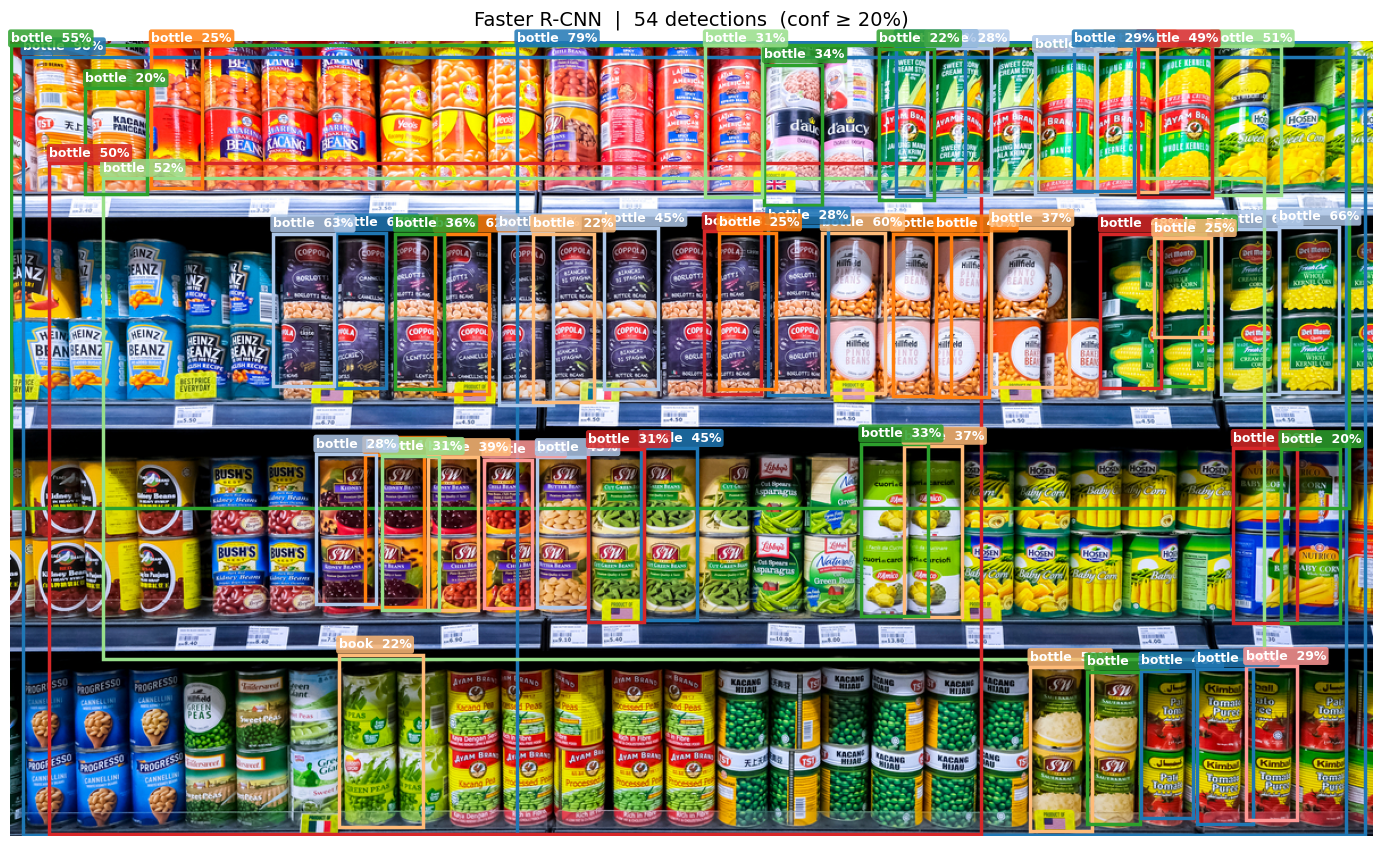


✓ Saved → detection_output.jpg


In [10]:
fig, ax = plt.subplots(1, figsize=(14, 9))
ax.imshow(img_rgb)

COLORS = plt.cm.get_cmap("tab20", max(len(f_boxes), 1))

for i, (box, score, cls) in enumerate(zip(f_boxes, f_scores, f_classes)):
    ymin, xmin, ymax, xmax = box
    x1, y1 = int(xmin * w), int(ymin * h)
    bw, bh  = int((xmax - xmin) * w), int((ymax - ymin) * h)

    color = COLORS(i % 20)
    label = COCO_LABELS.get(cls, f"cls {cls}")

    rect = patches.Rectangle((x1, y1), bw, bh,
                              linewidth=2.5, edgecolor=color, facecolor="none")
    ax.add_patch(rect)
    ax.text(x1, max(y1 - 6, 0), f"{label}  {score*100:.0f}%",
            color="white", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=color, alpha=0.85, edgecolor="none"))

ax.set_title(f"Faster R-CNN  |  {len(f_boxes)} detections  (conf ≥ {MIN_CONF*100:.0f}%)",
             fontsize=14, pad=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ Saved → {OUTPUT_PATH}")